# Task 1 — Idiom Detection Benchmark

Classify whether a sentence uses an expression **idiomatically** or **literally**.

We evaluate three models:
- TF-IDF + Logistic Regression
- DistilBERT
- RoBERTa

This notebook follows a clean and reproducible benchmark pipeline and saves only the final artifacts needed for the demo notebook.

In [1]:
# 1.1 Setup Paths and Seed

from pathlib import Path
import random
import os
import warnings
import numpy as np

# Ignore unnecessary warnings to keep notebook output clean
warnings.filterwarnings("ignore")

# Fixed seed for reproducibility
SEED = 42

# Set Python and NumPy random seeds
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Main artifact folders for Task 1
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
ARTIFACTS_DIR = PROJECT_DIR / "artifacts" / "task1"

MODELS_DIR = ARTIFACTS_DIR / "models"
EVAL_DIR = ARTIFACTS_DIR / "evaluation"
FIG_DIR = EVAL_DIR / "figures"

# Create folders if they do not already exist
for folder in [ARTIFACTS_DIR, MODELS_DIR, EVAL_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Seed:", SEED)
print("Artifacts directory:", ARTIFACTS_DIR.resolve())

Seed: 42
Artifacts directory: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task1


In [2]:
# 1.2 Install Missing Libraries(if needed)

import sys
import importlib

def ensure_package(import_name: str, pip_name: str | None = None):
    """
    Import a package if available.
    If missing, install it silently with pip, then import it.
    """
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
        print(f"{import_name}: already installed")
    except ImportError:
        print(f"{import_name}: installing...")
        !{sys.executable} -m pip install -q {pip_name}
        importlib.import_module(import_name)
        print(f"{import_name}: installed")

# Core libraries used in this notebook
ensure_package("pandas")
ensure_package("datasets")
ensure_package("sklearn", "scikit-learn")
ensure_package("matplotlib")
ensure_package("transformers")
ensure_package("torch")
ensure_package("evaluate")

pandas: already installed
datasets: already installed
sklearn: already installed
matplotlib: already installed
transformers: already installed
torch: already installed
evaluate: already installed


In [3]:
# 1.3 Import Libraries and Print Versions

import json
import pandas as pd
import matplotlib.pyplot as plt

import datasets
import sklearn
import transformers
import torch
import evaluate

print("pandas       :", pd.__version__)
print("datasets     :", datasets.__version__)
print("scikit-learn :", sklearn.__version__)
print("transformers :", transformers.__version__)
print("torch        :", torch.__version__)
print("evaluate     :", evaluate.__version__)

# Detect device once and reuse later
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device       :", device)

pandas       : 2.2.2
datasets     : 4.8.4
scikit-learn : 1.8.0
transformers : 4.41.2
torch        : 2.5.1+cu121
evaluate     : 0.4.6
Device       : cuda


## 2. Load and Prepare Dataset

Load the high-quality IdiomX dataset directly from Hugging Face.

This ensures:
- clean data (no additional filtering required)
- reproducibility
- consistency across benchmark tasks

In [4]:
# 2.1 Load high-quality IdiomX from Hugging Face

from datasets import load_dataset

HF_DATASET_NAME = "aymansharara/IdiomX"
HF_CONFIG_NAME = "idiomx_high_quality"  # <-- confirm exact name

dataset = load_dataset(HF_DATASET_NAME, HF_CONFIG_NAME)

print("Available splits:", list(dataset.keys()))
dataset

Available splits: ['idiomx_high_quality_train', 'idiomx_high_quality_test']


DatasetDict({
    idiomx_high_quality_train: Dataset({
        features: ['idiom_id', 'idiom_canonical', 'example', 'example_usage_label', 'idiom_canonical_meaning', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'example_raw', 'example_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'idiom_surface', 'pos', 'tags', 'idiom_confidence', 'is_example_idiom', 'is_generated_example', 'is_adversarial_example', 'meaning_language', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_in_example_arabic', 'enrichment_model', 'enrichment_version', 'validation_status', 'context_type', 'source_style', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'explanation_en', 'explanation_ar', 'minimal_pair_id', 'paraphrase_group_id', 'adversarial_type', 'expected

### 2.2 Merge High-Quality Splits and Keep Core Columns

We merge the released high-quality splits into one dataset, then keep only the columns required for Task 1.

A new leakage-aware split will be created later for the benchmark.

In [5]:
# 2.2 Merge high-quality splits and keep Task 1 columns

# Convert Hugging Face splits to pandas
df_train_raw = dataset["idiomx_high_quality_train"].to_pandas()
df_test_raw = dataset["idiomx_high_quality_test"].to_pandas()

# Merge both released splits before building our own benchmark split
df_raw = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

# Keep only columns needed for Task 1
task1_columns = [
    "idiom_id",
    "idiom_canonical",
    "idiom_surface",
    "example",
    "example_normalized",
    "example_usage_label",
    "minimal_pair_id",
    "context_type",
    "source_style",
    "sentence_length_words"
]

df_raw = df_raw[task1_columns].copy()

print("Merged shape:", df_raw.shape)
df_raw.head()

Merged shape: (123022, 10)


,idiom_id,idiom_canonical,idiom_surface,example,example_normalized,example_usage_label,minimal_pair_id,context_type,source_style,sentence_length_words
0,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,Please ’ark at ’ee the microchip here to obser...,please ark at ee the microchip here to observe...,literal,pair_0bd2fe08fbde,formal,synthetic_narrative,13
1,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,Can you ’ark at ’ee how clear the sound is fro...,can you ark at ee how clear the sound is from ...,literal,pair_4e9067ca68d8,social_media,synthetic_narrative,15
2,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,Can you ’ark at ’ee the diagram to find the au...,can you ark at ee the diagram to find the audi...,literal,pair_1a65f6e3f92f,question,synthetic_narrative,12
3,idiomx_7fd1dd45c159,'fraid so,'fraid so,"'Fraid so, the meeting's been canceled.",fraid so the meetings been canceled,idiomatic,pair_22baaea11584,dialogue,synthetic_narrative,6
4,idiomx_7fd1dd45c159,'fraid so,'fraid so,"When asked if the project was delayed, he said...",when asked if the project was delayed he said ...,idiomatic,pair_58c8a334b591,narrative,synthetic_narrative,11


In [6]:
# 2.3 Keep idiomatic/literal only and build split group key

# Keep only binary Task 1 labels
df_task1 = df_raw[df_raw["example_usage_label"].isin(["idiomatic", "literal"])].copy()

# Map labels to binary
label_map = {
    "literal": 0,
    "idiomatic": 1
}
df_task1["label"] = df_task1["example_usage_label"].map(label_map)

# Use minimal_pair_id when available; otherwise fallback to normalized sentence
df_task1["split_group"] = df_task1["minimal_pair_id"].fillna(df_task1["example_normalized"])

# Reset index for cleanliness
df_task1 = df_task1.reset_index(drop=True)

print("Task 1 shape:", df_task1.shape)
print("\nLabel distribution:")
print(df_task1["label"].value_counts().sort_index())
df_task1.head()

Task 1 shape: (116878, 12)

Label distribution:
label
0    66226
1    50652
Name: count, dtype: int64


,idiom_id,idiom_canonical,idiom_surface,example,example_normalized,example_usage_label,minimal_pair_id,context_type,source_style,sentence_length_words,label,split_group
0,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,Please ’ark at ’ee the microchip here to obser...,please ark at ee the microchip here to observe...,literal,pair_0bd2fe08fbde,formal,synthetic_narrative,13,0,pair_0bd2fe08fbde
1,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,Can you ’ark at ’ee how clear the sound is fro...,can you ark at ee how clear the sound is from ...,literal,pair_4e9067ca68d8,social_media,synthetic_narrative,15,0,pair_4e9067ca68d8
2,idiomx_543ff4605a0e,'ark at 'ee,'ark at 'ee,Can you ’ark at ’ee the diagram to find the au...,can you ark at ee the diagram to find the audi...,literal,pair_1a65f6e3f92f,question,synthetic_narrative,12,0,pair_1a65f6e3f92f
3,idiomx_7fd1dd45c159,'fraid so,'fraid so,"'Fraid so, the meeting's been canceled.",fraid so the meetings been canceled,idiomatic,pair_22baaea11584,dialogue,synthetic_narrative,6,1,pair_22baaea11584
4,idiomx_7fd1dd45c159,'fraid so,'fraid so,"When asked if the project was delayed, he said...",when asked if the project was delayed he said ...,idiomatic,pair_58c8a334b591,narrative,synthetic_narrative,11,1,pair_58c8a334b591


## 3. Leakage-Aware Train/Test Split

We create a custom split to avoid data leakage.

Strategy:
- Group by `split_group` (minimal pairs or normalized sentences)
- Ensure no group appears in both train and test
- Shuffle with fixed seed for reproducibility

In [7]:
# 3.1 Leakage-aware split

from sklearn.model_selection import train_test_split

# Get unique groups (to avoid leakage)
unique_groups = df_task1["split_group"].dropna().unique()

print("Total groups:", len(unique_groups))

# Split groups (NOT rows)
train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

# Assign rows based on group membership
df_train = df_task1[df_task1["split_group"].isin(train_groups)].copy()
df_test = df_task1[df_task1["split_group"].isin(test_groups)].copy()

print("\nTrain shape:", df_train.shape)
print("Test shape :", df_test.shape)

# Check no leakage
leakage = set(df_train["split_group"]).intersection(set(df_test["split_group"]))
print("\nLeakage groups:", len(leakage))

Total groups: 74591

Train shape: (93411, 12)
Test shape : (23467, 12)

Leakage groups: 0


### 3.2 Label Distribution Check

We verify that the split maintains a balanced distribution of idiomatic and literal examples.

In [8]:
# 3.2 Label distribution

print("Train distribution:")
print(df_train["label"].value_counts(normalize=True))

print("\nTest distribution:")
print(df_test["label"].value_counts(normalize=True))

Train distribution:
label
0    0.567117
1    0.432883
Name: proportion, dtype: float64

Test distribution:
label
0    0.564665
1    0.435335
Name: proportion, dtype: float64


## 4. Baseline Model: TF-IDF + Logistic Regression

We establish a strong classical baseline using TF-IDF features combined with Logistic Regression.

- TF-IDF captures word importance and local phrase patterns.
- Logistic Regression provides a fast and effective linear classifier.
- This baseline serves as a reference to evaluate the added value of transformer-based models.

In [9]:
# 4.1 TF-IDF + Logistic Regression

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Use normalized text for better consistency
TEXT_COLUMN = "example_normalized"

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=30000,       # limit features for speed and stability
    ngram_range=(1, 2),       # unigrams + bigrams
    min_df=2                  # ignore rare noise
)

# Fit on train, transform both
X_train = tfidf.fit_transform(df_train[TEXT_COLUMN])
X_test = tfidf.transform(df_test[TEXT_COLUMN])

y_train = df_train["label"]
y_test = df_test["label"]

print("TF-IDF shapes:", X_train.shape, X_test.shape)

# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

TF-IDF shapes: (93411, 30000) (23467, 30000)

Accuracy: 0.8732262325819236

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.89     13251
           1       0.86      0.85      0.85     10216

    accuracy                           0.87     23467
   macro avg       0.87      0.87      0.87     23467
weighted avg       0.87      0.87      0.87     23467



### 4.2 Baseline Evaluation

We visualize model performance using a confusion matrix and store key metrics for later comparison.

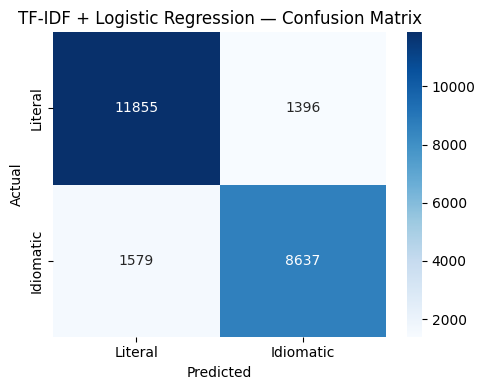

Saved figure to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task1\evaluation\figures\baseline_confusion_matrix.png
Saved metrics to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task1\evaluation\baseline_metrics.json


{'model': 'TF-IDF + LogisticRegression',
 'accuracy': 0.8732262325819236,
 'f1_macro': 0.8707966554637225}

In [10]:
# 4.2 Confusion Matrix + Save Metrics

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Literal", "Idiomatic"],
            yticklabels=["Literal", "Idiomatic"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TF-IDF + Logistic Regression — Confusion Matrix")
plt.tight_layout()

# Save figure for paper
fig_path = FIG_DIR / "baseline_confusion_matrix.png"
plt.savefig(fig_path)
plt.show()

print("Saved figure to:", fig_path)


# Save metrics for comparison later
baseline_results = {
    "model": "TF-IDF + LogisticRegression",
    "accuracy": float(acc),
    "f1_macro": float(classification_report(y_test, y_pred, output_dict=True)["macro avg"]["f1-score"])
}

# Save to JSON
import json

metrics_path = EVAL_DIR / "baseline_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(baseline_results, f, indent=4)

print("Saved metrics to:", metrics_path)

baseline_results

## 5. Transformer Model: DistilBERT

We fine-tune DistilBERT for idiom detection.

- DistilBERT is a lightweight transformer that captures contextual meaning beyond surface word patterns.
- It provides a strong neural baseline while remaining efficient.
- This model allows comparison between classical methods and more advanced transformer architectures.

In [11]:
# 5.1 Prepare datasets for Hugging Face

from datasets import Dataset

TEXT_COLUMN = "example_normalized"

# Convert pandas → HF Dataset (WITHOUT index column)
train_ds = Dataset.from_pandas(
    df_train[[TEXT_COLUMN, "label"]],
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    df_test[[TEXT_COLUMN, "label"]],
    preserve_index=False
)

train_ds, test_ds

(Dataset({
     features: ['example_normalized', 'label'],
     num_rows: 93411
 }),
 Dataset({
     features: ['example_normalized', 'label'],
     num_rows: 23467
 }))

### 5.2 Tokenization

We tokenize the input text using the DistilBERT tokenizer.

- Text is converted into token IDs required by the model.
- Sequences are truncated and padded to a fixed length for efficient batching.

In [12]:
# 5.2 Tokenization

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(example):
    return tokenizer(
        example[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=128  # enough for most sentences
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

# Remove raw text to speed training
train_ds = train_ds.remove_columns([TEXT_COLUMN])
test_ds = test_ds.remove_columns([TEXT_COLUMN])

train_ds.set_format("torch")
test_ds.set_format("torch")

train_ds

Map: 100%|██████████████████████████████████████████████████████████████| 23467/23467 [00:02<00:00, 9874.99 examples/s]


Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 93411
})

### 5.3 Model Training

We fine-tune DistilBERT on the training data for idiom detection.

- The model is trained using standard fine-tuning settings.
- Evaluation is performed at each epoch to monitor performance.
- The same configuration is used across models to ensure fair comparison.

In [13]:
# 5.3 Train DistilBERT

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds)
    }

training_args = TrainingArguments(
    output_dir=str(MODELS_DIR / "distilbert"),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,  # fast but strong baseline
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="no",  # avoid too many checkpoints
    logging_steps=200,
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.222400,0.224170,0.909618
2,0.158200,0.237611,0.922743


TrainOutput(global_step=11678, training_loss=0.20971442673544827, metrics={'train_runtime': 1072.0844, 'train_samples_per_second': 174.261, 'train_steps_per_second': 10.893, 'total_flos': 6186956087927808.0, 'train_loss': 0.20971442673544827, 'epoch': 2.0})

### 5.4 Evaluation

We evaluate the trained model on the test set.

- Accuracy and classification metrics are reported.
- Performance is analyzed across both idiomatic and literal classes.

In [14]:
# 5.4 Evaluate DistilBERT

preds = trainer.predict(test_ds)

y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

from sklearn.metrics import classification_report, confusion_matrix

acc_distil = accuracy_score(y_true, y_pred)

print("DistilBERT Accuracy:", acc_distil)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

DistilBERT Accuracy: 0.922742574679337

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     13251
           1       0.92      0.90      0.91     10216

    accuracy                           0.92     23467
   macro avg       0.92      0.92      0.92     23467
weighted avg       0.92      0.92      0.92     23467



### 5.5 Confusion Matrix

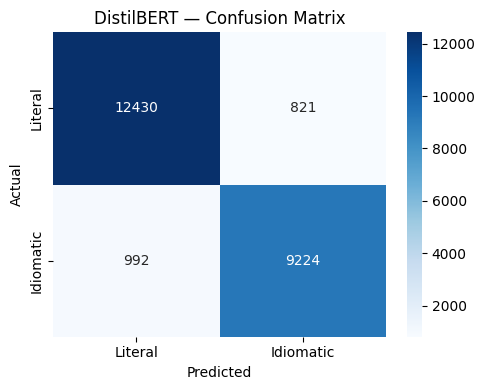

In [15]:
# 5.5 Confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Literal", "Idiomatic"],
            yticklabels=["Literal", "Idiomatic"])

plt.title("DistilBERT — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(FIG_DIR / "distilbert_confusion_matrix.png")
plt.show()

### 5.6 Save DistilBERT Results

We store evaluation metrics for later comparison with other models.

In [16]:
# 5.6 Save DistilBERT metrics

distilbert_results = {
    "model": "DistilBERT",
    "accuracy": float(acc_distil),
    "f1_macro": float(classification_report(y_true, y_pred, output_dict=True)["macro avg"]["f1-score"])
}

import json

metrics_path = EVAL_DIR / "distilbert_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(distilbert_results, f, indent=4)

print("Saved metrics to:", metrics_path)

distilbert_results

Saved metrics to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task1\evaluation\distilbert_metrics.json


{'model': 'DistilBERT',
 'accuracy': 0.922742574679337,
 'f1_macro': 0.9212731933226221}

## 6. Strong Transformer Model — RoBERTa

We fine-tune RoBERTa, a stronger transformer model, for idiom detection.

- RoBERTa provides deeper contextual understanding compared to lighter models.
- It allows us to evaluate the impact of increased model capacity on performance.
- Results are compared against both the baseline and DistilBERT.

In [18]:
# 6.1 Load RoBERTa model and prepare datasets

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset

MODEL_NAME = "roberta-base"

# Initialize tokenizer (different from DistilBERT → must re-tokenize)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


# Tokenization function:
# - converts text → token ids
# - ensures fixed length for batching
def tokenize(example):
    return tokenizer(
        example[TEXT_COLUMN],        # input sentence
        truncation=True,             # cut long sequences
        padding="max_length",        # pad to fixed length
        max_length=128               # sufficient for this task
    )


# Re-create datasets (clean → no leftover columns from previous model)
train_ds_roberta = Dataset.from_pandas(
    df_train[[TEXT_COLUMN, "label"]],
    preserve_index=False
)

test_ds_roberta = Dataset.from_pandas(
    df_test[[TEXT_COLUMN, "label"]],
    preserve_index=False
)


# Apply tokenization to entire dataset
train_ds_roberta = train_ds_roberta.map(tokenize, batched=True)
test_ds_roberta = test_ds_roberta.map(tokenize, batched=True)


# Remove raw text column (not needed after tokenization)
train_ds_roberta = train_ds_roberta.remove_columns([TEXT_COLUMN])
test_ds_roberta = test_ds_roberta.remove_columns([TEXT_COLUMN])


# Set format for PyTorch training
train_ds_roberta.set_format("torch")
test_ds_roberta.set_format("torch")


# Load RoBERTa classification model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2   # binary classification (idiomatic vs literal)
)

train_ds_roberta

Map: 100%|█████████████████████████████████████████████████████████████| 23467/23467 [00:02<00:00, 10256.21 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 93411
})

### 6.2 Model Training

We fine-tune RoBERTa on the training data for idiom detection.

- The model is trained using standard fine-tuning settings.
- Evaluation is performed at each epoch to monitor performance.
- The same configuration as DistilBERT is used to ensure fair comparison.

In [19]:
# 6.2 Train RoBERTa

from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score

# Metric function:
# - converts logits → predicted labels
# - computes accuracy for evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds)
    }


# Training configuration:
# - same setup as DistilBERT for fair comparison
# - small number of epochs for efficiency
training_args = TrainingArguments(
    output_dir=str(MODELS_DIR / "roberta"),  # where model outputs would go
    learning_rate=2e-5,                      # standard fine-tuning LR
    per_device_train_batch_size=16,          # batch size for training
    per_device_eval_batch_size=16,           # batch size for evaluation
    num_train_epochs=2,                      # short training (fast + sufficient)
    weight_decay=0.01,                       # regularization
    evaluation_strategy="epoch",             # evaluate each epoch
    save_strategy="no",                      # avoid saving checkpoints
    logging_steps=200,                       # log progress every N steps
    seed=SEED                                # reproducibility
)


# Trainer:
# - handles training loop, evaluation, batching
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_roberta,
    eval_dataset=test_ds_roberta,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# Start training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.230700,0.204698,0.922146
2,0.173100,0.248719,0.930583


TrainOutput(global_step=11678, training_loss=0.22049549357248793, metrics={'train_runtime': 1989.4224, 'train_samples_per_second': 93.908, 'train_steps_per_second': 5.87, 'total_flos': 1.228873339611648e+16, 'train_loss': 0.22049549357248793, 'epoch': 2.0})

### 6.3 Evaluation

In [20]:
# 6.3 Evaluate RoBERTa

preds = trainer.predict(test_ds_roberta)

y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

from sklearn.metrics import classification_report, confusion_matrix

acc_roberta = accuracy_score(y_true, y_pred)

print("RoBERTa Accuracy:", acc_roberta)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

RoBERTa Accuracy: 0.9305833723952784

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     13251
           1       0.92      0.92      0.92     10216

    accuracy                           0.93     23467
   macro avg       0.93      0.93      0.93     23467
weighted avg       0.93      0.93      0.93     23467



### 6.4 Confusion Matrix

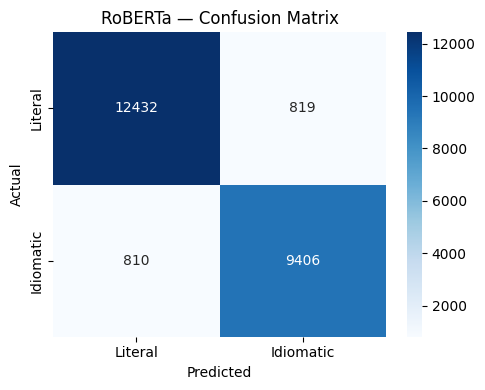

In [21]:
# 6.4 Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Literal", "Idiomatic"],
            yticklabels=["Literal", "Idiomatic"])

plt.title("RoBERTa — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(FIG_DIR / "roberta_confusion_matrix.png")
plt.show()

### 6.5 Save RoBERTa Results

We store evaluation metrics for comparison across models.

In [22]:
# 6.5 Save RoBERTa metrics

roberta_results = {
    "model": "RoBERTa",
    "accuracy": float(acc_roberta),
    "f1_macro": float(classification_report(y_true, y_pred, output_dict=True)["macro avg"]["f1-score"])
}

import json

metrics_path = EVAL_DIR / "roberta_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(roberta_results, f, indent=4)

print("Saved metrics to:", metrics_path)

roberta_results

Saved metrics to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task1\evaluation\roberta_metrics.json


{'model': 'RoBERTa',
 'accuracy': 0.9305833723952784,
 'f1_macro': 0.9294096427316345}

## 7. Model Comparison

We compare all models to highlight performance differences across approaches.

In [23]:
# 7. Model comparison table

import pandas as pd

results_df = pd.DataFrame([
    baseline_results,
    distilbert_results,
    roberta_results
])

# Sort by accuracy (best model on top)
results_df = results_df.sort_values(by="accuracy", ascending=False)

results_df

,model,accuracy,f1_macro
2,RoBERTa,0.930583,0.929410
1,DistilBERT,0.922743,0.921273
0,TF-IDF + LogisticRegression,0.873226,0.870797


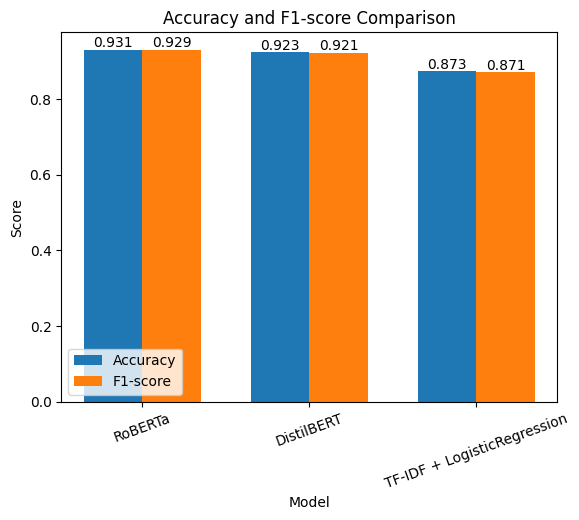

In [42]:
import numpy as np

x = np.arange(len(results_df))
width = 0.35

plt.figure()

bars1 = plt.bar(x - width/2, results_df["accuracy"], width, label="Accuracy")
bars2 = plt.bar(x + width/2, results_df["f1_macro"], width, label="F1-score")

# Add labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha='center',
            va='bottom'
        )

plt.xticks(x, results_df["model"], rotation=20)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Accuracy and F1-score Comparison")

plt.legend()
plt.show()

## 8. ROC Curve Analysis

We analyze model performance across different classification thresholds using ROC curves.

- This shows the trade-off between true positive rate and false positive rate.
- A higher AUC indicates better overall discrimination ability.

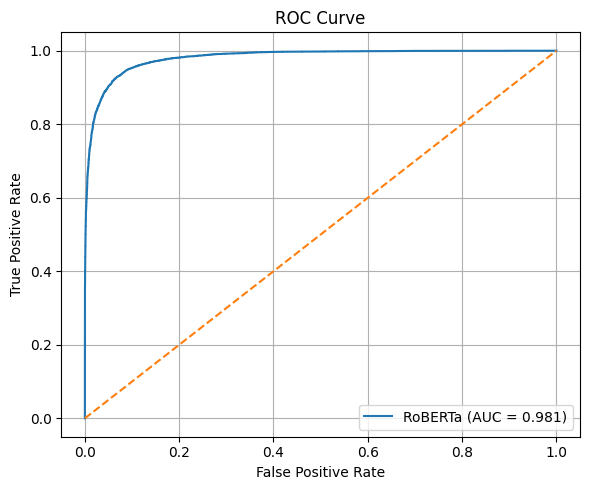

AUC: 0.9811


In [24]:
# 8. ROC Curve

from sklearn.metrics import roc_curve, auc

# Get probabilities (RoBERTa)
probs = preds.predictions[:, 1]

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"RoBERTa (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIG_DIR / "roberta_roc_curve.png")
plt.show()

print("AUC:", round(roc_auc, 4))

### Insight

The ROC curve shows that RoBERTa achieves a very high AUC of 0.981, indicating excellent separation between idiomatic and literal classes.

- The curve quickly rises toward the top-left corner, showing strong performance even at low false positive rates.
- This suggests the model is highly confident and effective in distinguishing between the two classes.
- The high AUC confirms that performance is robust across different decision thresholds.

## 9. Score Distribution Analysis

We analyze the distribution of prediction confidence scores for correct and incorrect predictions.

This helps understand model confidence and identify potential overlap between classes.

Correct mean: 0.9884
Incorrect mean: 0.908


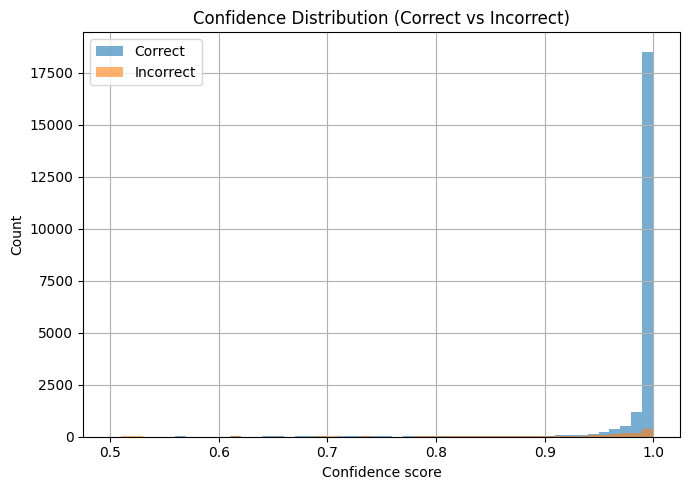

In [26]:
# 9. Score Distribution (Correct vs Incorrect) — FIXED

from scipy.special import softmax

# Convert logits → probabilities
probs = softmax(preds.predictions, axis=1)

# Confidence = probability of predicted class
confidence = np.max(probs, axis=1)

correct_mask = (y_pred == y_true)
incorrect_mask = (y_pred != y_true)

correct_scores = confidence[correct_mask]
incorrect_scores = confidence[incorrect_mask]

print("Correct mean:", round(correct_scores.mean(), 4))
print("Incorrect mean:", round(incorrect_scores.mean(), 4))

plt.figure(figsize=(7, 5))

plt.hist(correct_scores, bins=50, alpha=0.6, label="Correct")
plt.hist(incorrect_scores, bins=50, alpha=0.6, label="Incorrect")

plt.xlabel("Confidence score")
plt.ylabel("Count")
plt.title("Confidence Distribution (Correct vs Incorrect)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIG_DIR / "confidence_distribution_correct_vs_incorrect.png")
plt.show()

### Insight

The confidence distribution shows a clear separation between correct and incorrect predictions.

- Correct predictions are highly concentrated near confidence scores close to 1.0.
- Incorrect predictions are more dispersed and generally have lower confidence.
- This indicates that the model is not only accurate but also well-calibrated, assigning higher confidence to correct decisions.

The sharp peak near high confidence values suggests that the model is very certain in most cases, which aligns with the high overall accuracy and AUC observed earlier.

## 10. Error Analysis

We analyze incorrectly classified examples to understand common failure cases.

In [27]:
# 10. Error Analysis — sample incorrect predictions

errors_df = df_test.copy()
errors_df["y_true"] = y_true
errors_df["y_pred"] = y_pred

# Keep only incorrect predictions
errors_df = errors_df[errors_df["y_true"] != errors_df["y_pred"]]

# Add confidence scores
errors_df["confidence"] = confidence[y_true != y_pred]

# Show top errors
errors_df[["example", "y_true", "y_pred", "confidence"]].head(10)

,example,y_true,y_pred,confidence
7,"Are you scared of the dark? Yes, 'fraid so.",0,1,0.961903
53,Just posted my quiz results: got an A for effo...,0,1,0.995819
154,The report outlines that currently there are B...,0,1,0.954974
269,"Oh great, my whispered secrets will become Chi...",0,1,0.999026
343,Can you explain what 'Delivered Ex Quay' means...,0,1,0.944891
516,Did Florence Nightingale really invent the mod...,0,1,0.991708
631,The donation was regarded as God's gift to the...,0,1,0.977969
727,He pulled out his pants and the Hoover flag wa...,1,0,0.992918
763,Why did you say ‘I am HIV positive’ in that se...,0,1,0.982705
824,"I can't swim, so I always avoid beach trips.",0,1,0.901824


### Insight

The error analysis reveals that most misclassifications occur in semantically ambiguous or context-dependent cases.

- Some errors arise when sentences can be interpreted both literally and idiomatically.
- The model occasionally assigns high confidence to incorrect predictions, indicating overconfidence in challenging cases.
- Certain expressions require deeper contextual or world knowledge beyond surface-level patterns.

These observations highlight that while the model performs strongly overall, ambiguity and nuanced meaning remain key challenges in idiom detection.

## 11. Error Distribution Analysis

We analyze how errors are distributed across confidence levels.

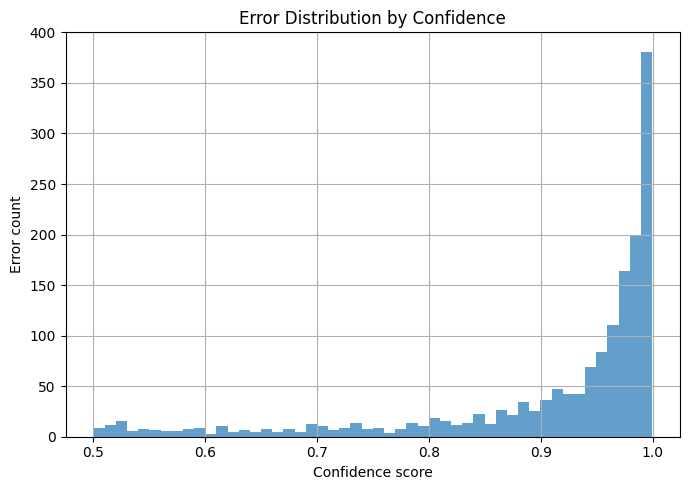

Mean error confidence: 0.908


In [28]:
# 11. Error Distribution

plt.figure(figsize=(7, 5))

plt.hist(errors_df["confidence"], bins=50, alpha=0.7)

plt.xlabel("Confidence score")
plt.ylabel("Error count")
plt.title("Error Distribution by Confidence")
plt.grid(True)
plt.tight_layout()

plt.savefig(FIG_DIR / "error_distribution.png")
plt.show()

print("Mean error confidence:", round(errors_df["confidence"].mean(), 4))

### Insight

The error distribution reveals that many incorrect predictions occur at high confidence levels.

- The mean confidence for errors is approximately 0.91, indicating that the model is often highly confident even when wrong.
- A significant number of errors are concentrated near confidence values close to 1.0.
- This suggests that the model is overconfident in certain ambiguous or misleading cases.

These results highlight that while overall accuracy is high, confidence alone is not always a reliable indicator of correctness. This motivates the need for calibration or more robust handling of ambiguous examples.

## 12. Har/d Negative Analysis

We examine the most confident incorrect predictions (hard negatives) to understand challenging cases.

In [29]:
# 12. Hard Negative Analysis

# Sort errors by highest confidence (most dangerous mistakes)
hard_negatives = errors_df.sort_values(by="confidence", ascending=False)

# Show top hard negatives
hard_negatives[["example", "y_true", "y_pred", "confidence"]].head(10)

,example,y_true,y_pred,confidence
75851,The scientist stuck their nose into the micros...,1,0,0.999517
62576,I pressed the fabric into service as a makeshi...,1,0,0.999515
43134,OMG they are always together! Literally joined...,1,0,0.999505
16230,How do pioneers circle the wagons to protect t...,0,1,0.999493
18487,"Yeah, he literally couldn’t get elected dogcat...",1,0,0.999493
12506,Is that rusty old bucket of bolts still runnin...,1,0,0.999470
61693,"Yeah, they went behind the barn to plough the ...",1,0,0.999464
73627,The equipment was soaking wet due to the unexp...,1,0,0.999460
108925,Did you accidentally pocket dial your friend w...,1,0,0.999455
109612,Could you put the wood in the hole before you ...,1,0,0.999452


### Insight

The hard negative analysis reveals that the most confident errors often involve highly ambiguous or misleading contexts.

- Many incorrect predictions occur with confidence above 0.99, indicating strong overconfidence.
- Several examples involve expressions that can plausibly be interpreted both literally and idiomatically.
- In some cases, subtle contextual cues determine the correct interpretation, which the model fails to fully capture.

These findings highlight that even strong models like RoBERTa struggle with nuanced or borderline idiomatic usage, suggesting that deeper semantic understanding remains a challenge.

## 13. Save Final Artifacts

We save the final RoBERTa model and tokenizer for reuse in the demo notebook.

In [30]:
# 13. Save final RoBERTa artifacts

from pathlib import Path

FINAL_MODEL_DIR = MODELS_DIR / "roberta"

# Save trained model weights and config
model.save_pretrained(FINAL_MODEL_DIR)

# Save matching tokenizer
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print("Saved model to:", FINAL_MODEL_DIR.resolve())

Saved model to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\artifacts\task1\models\roberta


## 14. Conclusion

In this benchmark, we evaluated idiom detection using both classical and transformer-based models.

- The TF-IDF + Logistic Regression baseline achieved strong performance, demonstrating that lexical features are effective for this task.
- Transformer models significantly improved results, with DistilBERT and RoBERTa achieving higher accuracy and better overall performance.
- RoBERTa achieved the best performance, indicating the benefit of stronger contextual modeling.

Additional analyses showed that:
- The model achieves high confidence and strong class separation.
- However, errors often occur in ambiguous or context-dependent cases.
- The model can be overconfident in certain incorrect predictions.

Overall, these results demonstrate that idiom detection is largely solvable with modern models, but challenging edge cases remain, particularly in nuanced or borderline contexts.